# Simplified Knowledge Graph Visualization

This notebook generates a simplified, Property-Graph-style visualization of the music recommendation Knowledge Graph. It deliberately bypasses strict RDF reification to visually demonstrate edge weights (like listening counts) directly between the `Listener` and `Track` nodes, making it ideal for the project proposal presentation.

In [1]:
!pip install networkx pygraphviz
# Note: pygraphviz requires Graphviz to be installed on your system (e.g., `sudo apt-get install graphviz graphviz-dev` on Linux or `brew install graphviz` on Mac)

/usr/lib/python3.14/site-packages/pygraphviz/agraph.py:1403: RuntimeWarning: Warning: Orthogonal edges do not currently handle edge labels. Try using xlabels.

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


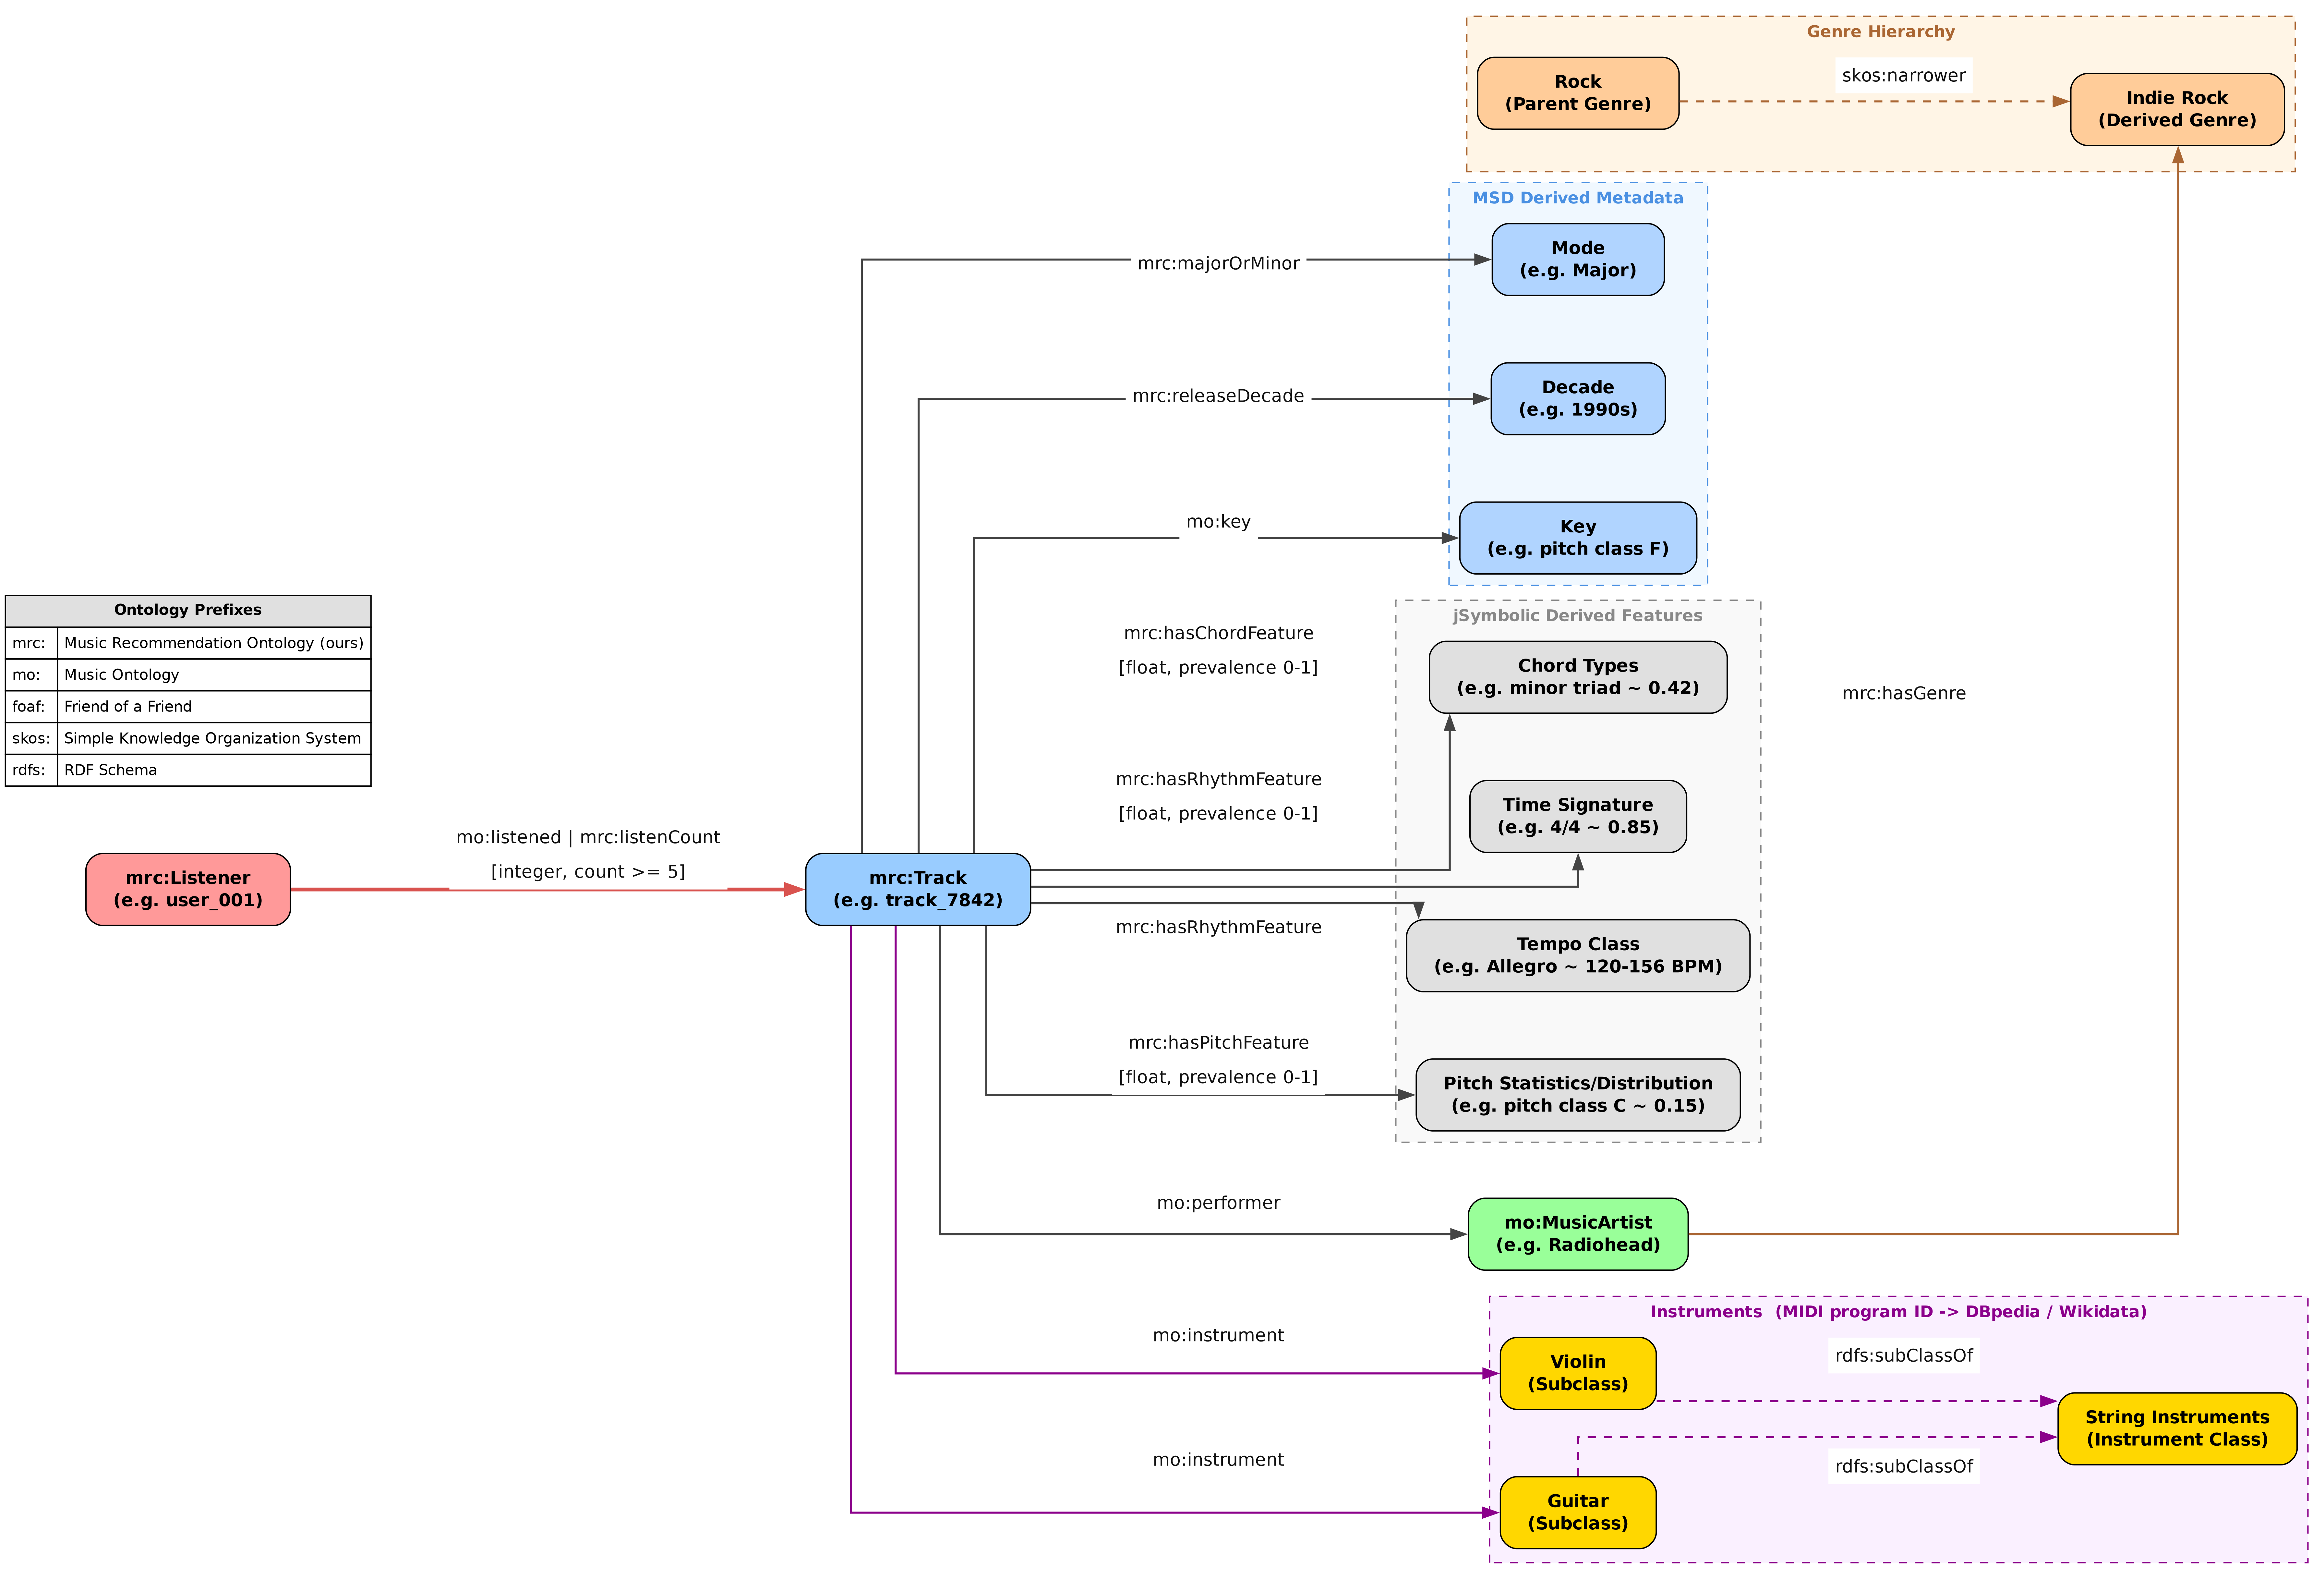

Graph saved as 'mrc_kg_abstract.png'


In [1]:
import io
import pygraphviz as pgv
from IPython.display import Image, display

# ─── Configuration ────────────────────────────────────────────────────────────
SAVE_OUTPUT = True
output_filename = "mrc_kg_abstract.png"
# ──────────────────────────────────────────────────────────────────────────────

color_map = {
    "Listener": "#FF9999",
    "Track":    "#99CCFF",
    "Artist":   "#99FF99",
    "Genre":    "#FFCC99",
    "Metadata": "#B0D4FF",
    "Feature":  "#E0E0E0",
    "External": "#FFD700",
}

A = pgv.AGraph(directed=True, strict=False)
A.graph_attr.update(
    rankdir="LR",
    dpi="300",
    nodesep="0.7",
    ranksep="1.6",
    fontname="Helvetica",
    compound="true",
    splines="ortho",
)

def add_node(graph, node_id, label, ntype, shape="box"):
    graph.add_node(
        node_id,
        label=label,
        style="filled, rounded",
        shape=shape,
        fillcolor=color_map.get(ntype, "white"),
        fontname="Helvetica-Bold",
        fontsize="13",
        margin="0.28,0.14",
    )

def make_html_label(label):
    label = label.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
    lines = label.split("\n")
    rows = "".join(f'<TR><TD ALIGN="CENTER">{l}</TD></TR>' for l in lines)
    return (
        f'<<TABLE BORDER="0" CELLBORDER="0" CELLSPACING="1" CELLPADDING="4" '
        f'BGCOLOR="white">{rows}</TABLE>>'
    )

def add_edge(g, src, dst, label, bold=False, color="#444444", dashed=False):
    g.add_edge(
        src, dst,
        label=make_html_label(label),
        fontname="Helvetica",
        fontsize="13",
        color=color,
        fontcolor="#111111",
        penwidth="2.8" if bold else "1.5",
        style="dashed" if dashed else "solid",
    )

# ── Core nodes ────────────────────────────────────────────────────────────────
add_node(A, "listener",    "mrc:Listener\n(e.g. user_001)",    "Listener")
add_node(A, "track",       "mrc:Track\n(e.g. track_7842)", "Track")
add_node(A, "artist",      "mo:MusicArtist\n(e.g. Radiohead)", "Artist")

# ── Cluster: Genre Hierarchy ──────────────────────────────────────────────────
genre_cluster = A.add_subgraph(
    name="cluster_genre",
    label="Genre Hierarchy",
    style="dashed",
    color="#AA6633",
    fontcolor="#AA6633",
    fontname="Helvetica-Bold",
    fontsize="12",
    bgcolor="#FFF5E6",
)
add_node(genre_cluster, "rock",      "Rock\n(Parent Genre)",        "Genre")
add_node(genre_cluster, "indie_rock","Indie Rock\n(Derived Genre)", "Genre")
genre_cluster.add_edge(
    "rock", "indie_rock",
    label=make_html_label("skos:narrower"),
    fontname="Helvetica", fontsize="13", fontcolor="#111111",
    color="#AA6633", penwidth="1.5", style="dashed",
)

# ── Cluster: Metadata ───────────────────────────────────────────────────────────
meta_cluster = A.add_subgraph(
    name="cluster_metadata",
    label="MSD Derived Metadata",
    style="dashed",
    color="#4A90E2",
    fontcolor="#4A90E2",
    fontname="Helvetica-Bold",
    fontsize="12",
    bgcolor="#F0F8FF",
)
add_node(meta_cluster, "decade",    "Decade\n(e.g. 1990s)",          "Metadata")
add_node(meta_cluster, "key",       "Key\n(e.g. pitch class F)",      "Metadata")
add_node(meta_cluster, "mode",      "Mode\n(e.g. Major)",             "Metadata")

# ── Cluster: jSymbolic Features ───────────────────────────────────────────────
feat_cluster = A.add_subgraph(
    name="cluster_features",
    label="jSymbolic Derived Features",
    style="dashed",
    color="#888888",
    fontcolor="#888888",
    fontname="Helvetica-Bold",
    fontsize="12",
    bgcolor="#F9F9F9",
)
add_node(feat_cluster, "tempo",     "Tempo Class\n(e.g. Allegro ~ 120-156 BPM)",           "Feature")
add_node(feat_cluster, "pitch",     "Pitch Statistics/Distribution\n(e.g. pitch class C ~ 0.15)", "Feature")
add_node(feat_cluster, "chord",     "Chord Types\n(e.g. minor triad ~ 0.42)",              "Feature")
add_node(feat_cluster, "timesig",   "Time Signature\n(e.g. 4/4 ~ 0.85)",                   "Feature")

# ── Cluster: Instruments (MIDI → DBpedia / Wikidata) ─────────────────────────
inst_cluster = A.add_subgraph(
    name="cluster_instruments",
    label="Instruments  (MIDI program ID -> DBpedia / Wikidata)",
    style="dashed",
    color="#8B008B",
    fontcolor="#8B008B",
    fontname="Helvetica-Bold",
    fontsize="12",
    bgcolor="#FAF0FF",
)
add_node(inst_cluster, "str_inst", "String Instruments\n(Instrument Class)", "External")
add_node(inst_cluster, "guitar",   "Guitar\n(Subclass)",                      "External")
add_node(inst_cluster, "violin",   "Violin\n(Subclass)",                      "External")

for child in ["guitar", "violin"]:
    inst_cluster.add_edge(
        child, "str_inst",
        label=make_html_label("rdfs:subClassOf"),
        fontname="Helvetica", fontsize="13", fontcolor="#111111",
        color="#8B008B", penwidth="1.5", style="dashed",
    )

# ── Backbone edges ────────────────────────────────────────────────────────────
add_edge(A, "listener", "track",      "mo:listened | mrc:listenCount\n[integer, count >= 5]", bold=True, color="#D9534F")
add_edge(A, "track",    "artist",     "mo:performer")
add_edge(A, "artist",   "indie_rock", "mrc:hasGenre", color="#AA6633")

# ── Track -> Metadata ─────────────────────────────────────────────────────────
add_edge(A, "track", "decade",  "mrc:releaseDecade")
add_edge(A, "track", "key",     "mo:key")
add_edge(A, "track", "mode",    "mrc:majorOrMinor")

# ── Track -> jSymbolic Features ───────────────────────────────────────────────
add_edge(A, "track", "tempo",   "mrc:hasRhythmFeature")
add_edge(A, "track", "pitch",   "mrc:hasPitchFeature\n[float, prevalence 0-1]")
add_edge(A, "track", "chord",   "mrc:hasChordFeature\n[float, prevalence 0-1]")
add_edge(A, "track", "timesig", "mrc:hasRhythmFeature\n[float, prevalence 0-1]")

# ── Track -> Instruments ──────────────────────────────────────────────────────
for inst in ["guitar", "violin"]:
    add_edge(A, "track", inst, "mo:instrument", color="#8B008B")

# ── Legend / Prefixes ─────────────────────────────────────────────────────────
prefix_label = (
    '<<TABLE BORDER="0" CELLBORDER="1" CELLSPACING="0" CELLPADDING="4" BGCOLOR="white">'
    '<TR><TD COLSPAN="2" BGCOLOR="#E0E0E0"><B>Ontology Prefixes</B></TD></TR>'
    '<TR><TD ALIGN="LEFT">mrc:</TD><TD ALIGN="LEFT">Music Recommendation Ontology (ours)</TD></TR>'
    '<TR><TD ALIGN="LEFT">mo:</TD><TD ALIGN="LEFT">Music Ontology</TD></TR>'
    '<TR><TD ALIGN="LEFT">foaf:</TD><TD ALIGN="LEFT">Friend of a Friend</TD></TR>'
    '<TR><TD ALIGN="LEFT">skos:</TD><TD ALIGN="LEFT">Simple Knowledge Organization System</TD></TR>'
    '<TR><TD ALIGN="LEFT">rdfs:</TD><TD ALIGN="LEFT">RDF Schema</TD></TR>'
    '</TABLE>>'
)
A.add_node("prefix_legend", label=prefix_label, shape="none", margin="0", fontname="Helvetica", fontsize="11")

# ── Render ────────────────────────────────────────────────────────────────────
if SAVE_OUTPUT:
    A.draw(output_filename, prog="dot")
    display(Image(filename=output_filename))
    print(f"Graph saved as '{output_filename}'")
else:
    buf = io.BytesIO()
    buf.write(A.draw(format="png", prog="dot"))
    buf.seek(0)
    display(Image(data=buf.read()))
    print("Graph displayed (not saved). Set SAVE_OUTPUT = True to write to disk.")
